## **Replicação de Artigos**

In [1]:
# Importando Bibliotecas
import os
import pandas as pd
import re

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Importando Modelos
from src.models.models_artigos.full_hrnet.full_hrnet import FullHRNet
from src.models.models_artigos.full_hrnet.full_hrnet_pretrained import FullHRNet_ImageNet
from src.models.models_artigos.resnet_point.two_stage_resnet import TwoStageResNet

# Importar sua classe existente
from src.vfss_dataset import VFSSImageDataset

from src.split_data import split_data_k_fold
from src.utils import (plot_image_with_mask,
                       get_script_relative_path,
                       get_project_root_directory,
                       get_corners_from_angle,
                       clahe,
                       modify_input,
                       load_points,
                       custom_collate_fn,
                       set_seed,
                       avalia_status_GPU,
                       resolve_dataframe_path)

# Importando classes/funções - Podar imports que não são chamados aqui.
from src.training.config import TrainingConfig
from src.training.loss import (LossCalculator,
                               FocalMSELoss,
                               FocalMSEMaskedLoss)
from src.training.holdout import holdout
from src.training.cross_validation import cross_validate
from src.evalutation.inference import display_inference

set_seed(42)

## **Full HR-Net**

### **Configuração**

In [ ]:
# Parametros Básicos Iniciais
width = 32

# Transformações
output_dim = (448, 448)

transform_augmentation_offline = A.Compose([
        A.PixelDropout(dropout_prob = 0.01, p = 0.5),
        A.ShiftScaleRotate(shift_limit = 0.06, scale_limit = 0.1, rotate_limit = 10, p = 0.5),
        A.Perspective(scale=(0.01, 0.02), keep_size=True, fit_output=False, p=0.5),
        A.CropAndPad(px=(-30, 30), p=0.5),
        A.AdvancedBlur(blur_limit= (3, 15), rotate_limit= (-90, 90), beta_limit= (0.5, 8.0), noise_limit= (0.9, 1.1), p= 0.5),
        A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
        A.GaussNoise(var_limit=(00.0, 100.0), mean=0, p=0.5),   # Ruído Gaussiano
        A.Resize(output_dim[0], output_dim[1])
    ],
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
    )

transform_puro = A.Compose([A.Resize(output_dim[0], output_dim[1]),
                       ToTensorV2()],
                      keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

# Configuração
config_fullhrnet = TrainingConfig(
         path_dataframe = "data/metadados/video_frame_metadata.csv",
         model_class    = FullHRNet_ImageNet,
         model_kwargs = {"num_keypoints": 2,
                         "width": width,
                         "pretrained_path": f"data/model_weights/FullHRNet_ImageNet/model_hrnet_w{width}_imagenet.pth"
                         },
         test_size      = 0.2,
         n_folds        = 5,
         dataset_class  = VFSSImageDataset,
         sigma_heatmap  = 20,

         # Hiperparâmetros do Modelo
         epochs             = 200,
         learning_rate      = 0.001,
         batch_size         = 8,
         patience           = 5,
         lr_patience        = 1e-10,
         optimizer          = torch.optim.Adam,
         optimizer_kwargs   = {},
         scheduler          = torch.optim.lr_scheduler.ReduceLROnPlateau,
         scheduler_kwargs   = {"mode":"min",
                               "factor":0.1,
                               "patience":3},

         # Offline Augmentation
         offline_augmentation    = True,
         transform_augmentation  = transform_augmentation_offline,
         augmentation_dir        = "data/frames_augmentation",
         n_aug                   = 5,

         # Funções e Transformações
         output_dim           = output_dim,
         modify_input_fn      = None, # modify_input,
         collate_fn           = custom_collate_fn,
         transform_train      = transform_puro,
         transform_validation = transform_puro,

         # Função de Loss
         criterion_roi       = nn.BCEWithLogitsLoss(),
         criterion_heatmap   = nn.MSELoss(),
         criterion_keypoints = None,
         weight_roi          = 0.0,
         weight_heatmap      = 1.0,
         weight_penalty      = 0.0,
         weight_keypoints    = 0.0,

         # Outros
         device          = "cuda" if torch.cuda.is_available() else "cpu",
         predict_roi     = False,
         width           = width
         )

# Avaliando Status do Uso da GPU
avalia_status_GPU()

Folds all: 92
Test: 23
Overall Dataset - Videos: 234 | Patients: 115 | Frames: 973 (100.0%)
Training + Validation Set - Videos: 192 | Patients: 92 | Frames: 795 (81.7%)
Test Set - Videos: 42 | Patients: 23 | Frames: 178 (18.3%)

Fold 1 - Videos: 41 | Patients: 19 | Frames: 174 (17.9%)
Fold 2 - Videos: 56 | Patients: 19 | Frames: 230 (23.6%)
Fold 3 - Videos: 40 | Patients: 18 | Frames: 168 (17.3%)
Fold 4 - Videos: 26 | Patients: 18 | Frames: 108 (11.1%)
Fold 5 - Videos: 29 | Patients: 18 | Frames: 115 (11.8%)


,split_name,n_videos,n_patients,n_frames,percentage_of_initial_frames,video_ids
0,fold_1,41,19,174,0.178828,"[101, 102, 103, 104, 105, 106, 107, 108, 109, ..."
1,fold_2,56,19,230,0.236382,"[129, 130, 131, 132, 136, 137, 138, 139, 140, ..."
2,fold_3,40,18,168,0.172662,"[122, 123, 125, 126, 127, 128, 152, 153, 154, ..."
3,fold_4,26,18,108,0.110997,"[10, 113, 114, 115, 116, 117, 118, 119, 120, 1..."
4,fold_5,29,18,115,0.118191,"[192, 193, 194, 195, 196, 197, 198, 199, 200, ..."
5,test_set,42,23,178,0.182939,"[100, 11, 13, 142, 143, 144, 145, 146, 147, 14..."



VERIFICAÇÃO DE GPU
PyTorch version: 2.2.2+cu121
CUDA disponível: True
CUDA version: 12.1
GPU: NVIDIA GeForce RTX 2080 Ti
Número de GPUs: 1



### **Treino/Validação**

In [ ]:
# Treinamento do Modelo

# Holdout Training sem tunagem

results = holdout(
    df_train=pd.concat([config_fullhrnet.list_df_folds[j] for j in range(1,config_fullhrnet.n_folds)], ignore_index=True),
    df_val=config_fullhrnet.list_df_folds[0],
    config=config_fullhrnet,
)

Arquivos antigos de augmentation apagados!


Offline Augmentation - Processando em Paralelo: 100%|██████████| 621/621 [00:32<00:00, 18.90it/s]


HRNet 32 inicializada com 39 camadas da ImageNet.


Treinando: 100%|██████████| 389/389 [00:51<00:00,  7.56it/s]


Época 1/200
  Train Loss: 0.1860 | Val Loss: 0.0103
  Val Components - ROI: 0.0000, Heatmap: 0.0103, Penalty: 0.0105
✓ Melhor modelo salvo (val_loss: 0.0103)


...

Época 21/200
  Train Loss: 0.0004 | Val Loss: 0.0012
  Val Components - ROI: 0.0000, Heatmap: 0.0012, Penalty: 0.0031


Treinando: 100%|██████████| 389/389 [00:18<00:00, 20.89it/s]


Época 22/200
  Train Loss: 0.0004 | Val Loss: 0.0012
  Val Components - ROI: 0.0000, Heatmap: 0.0012, Penalty: 0.0022


Treinando: 100%|██████████| 389/389 [00:18<00:00, 20.79it/s]


Época 23/200
  Train Loss: 0.0004 | Val Loss: 0.0012
  Val Components - ROI: 0.0000, Heatmap: 0.0012, Penalty: 0.0029
Early stopping ativado na época 23
✓ Checkpoint carregado: epoch 17, val_loss: 0.0011

Loss Final: 0.0011

RESULTADOS FINAIS
Média dos Folds: 0.0011 ± 0.0000
Melhor Fold: 1 (Loss: 0.0011)


### **Teste**


INICIANDO AVALIAÇÃO NO CONJUNTO DE TESTE
HRNet 32 inicializada com 39 camadas da ImageNet.
✓ Modelo carregado: data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_32W\fold_1_best.pth
  Epoch: 17
  Val Loss: 0.0011

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:05<00:00, 29.67it/s]



GERANDO VISUALIZAÇÕES
✓ Gráfico salvo: figs\FullHRNet_ImageNet\MSELoss_200ep_32W\fold1\loss_distributions.png


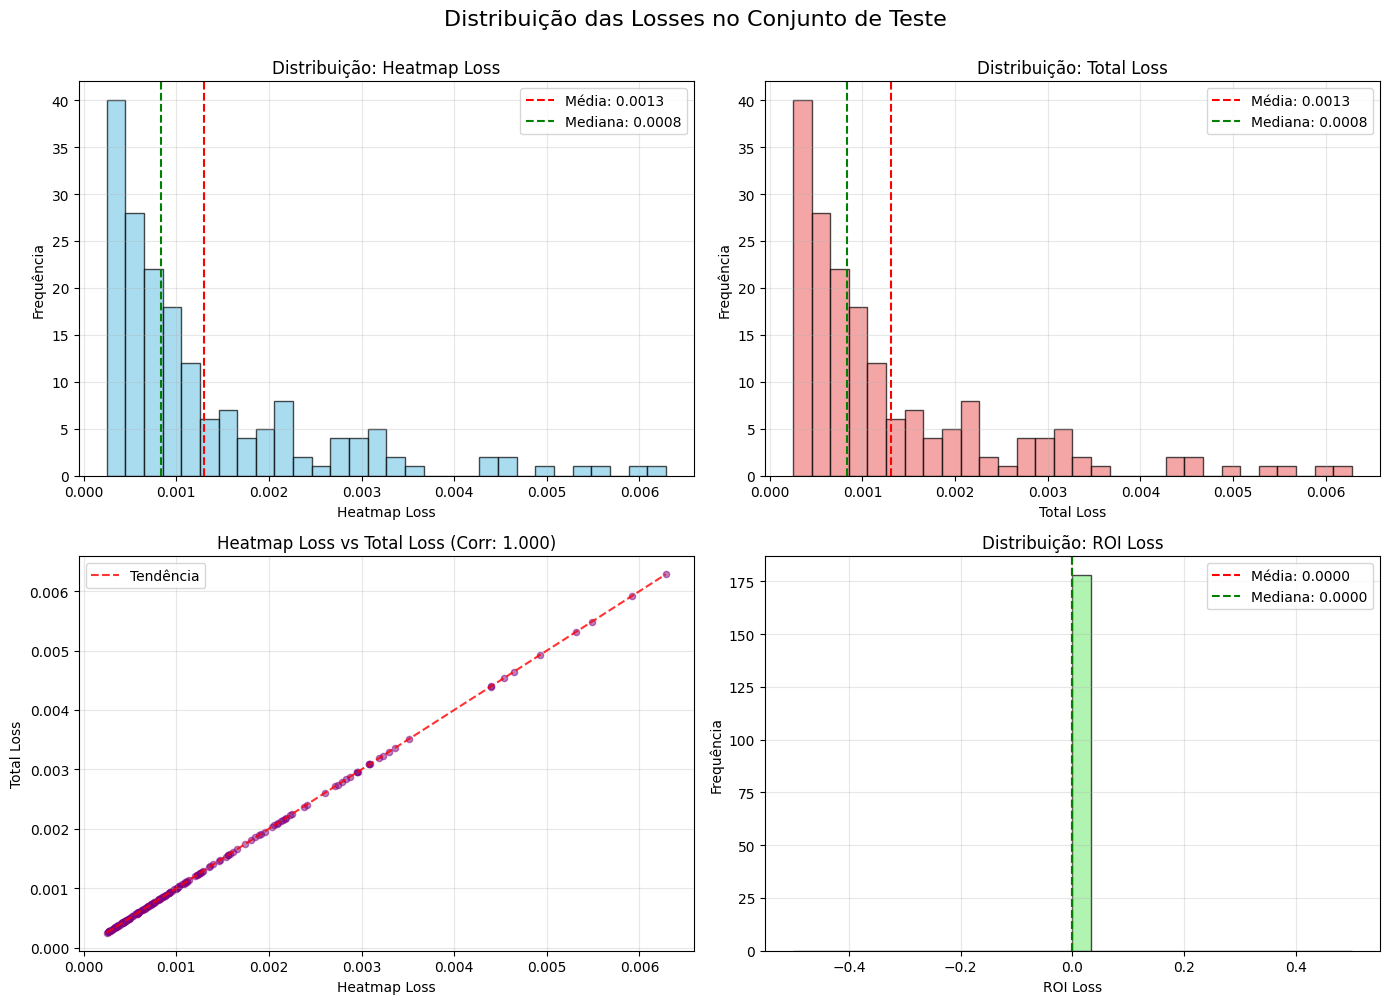

✓ Gráfico salvo: figs\FullHRNet_ImageNet\MSELoss_200ep_32W\fold1\keypoint_analysis.png


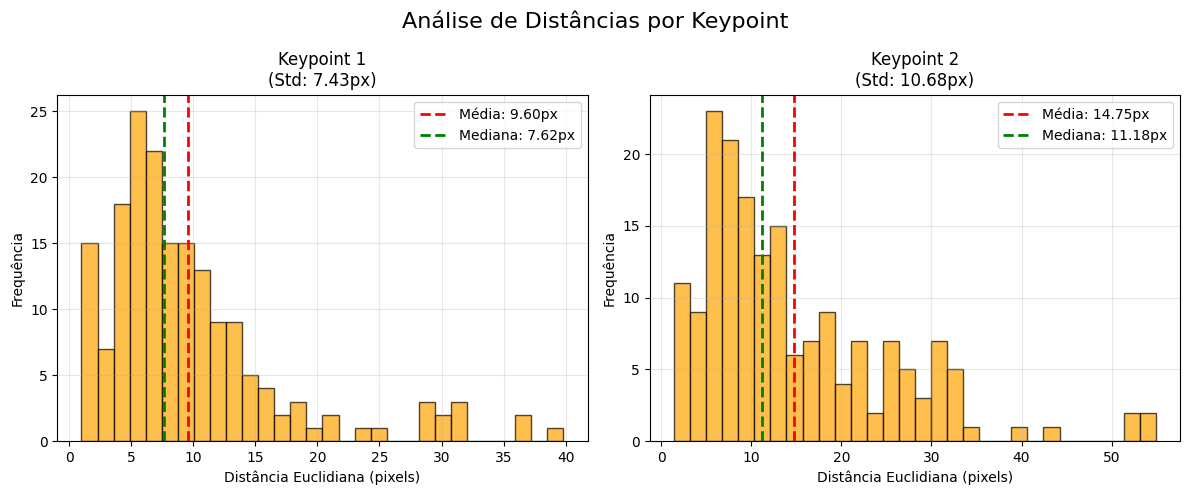


--- Visualizações para Keypoint 1 ---
✓ Figura salva: figs\FullHRNet_ImageNet\MSELoss_200ep_32W\fold1\predictions_by_distance_keypoint1.png


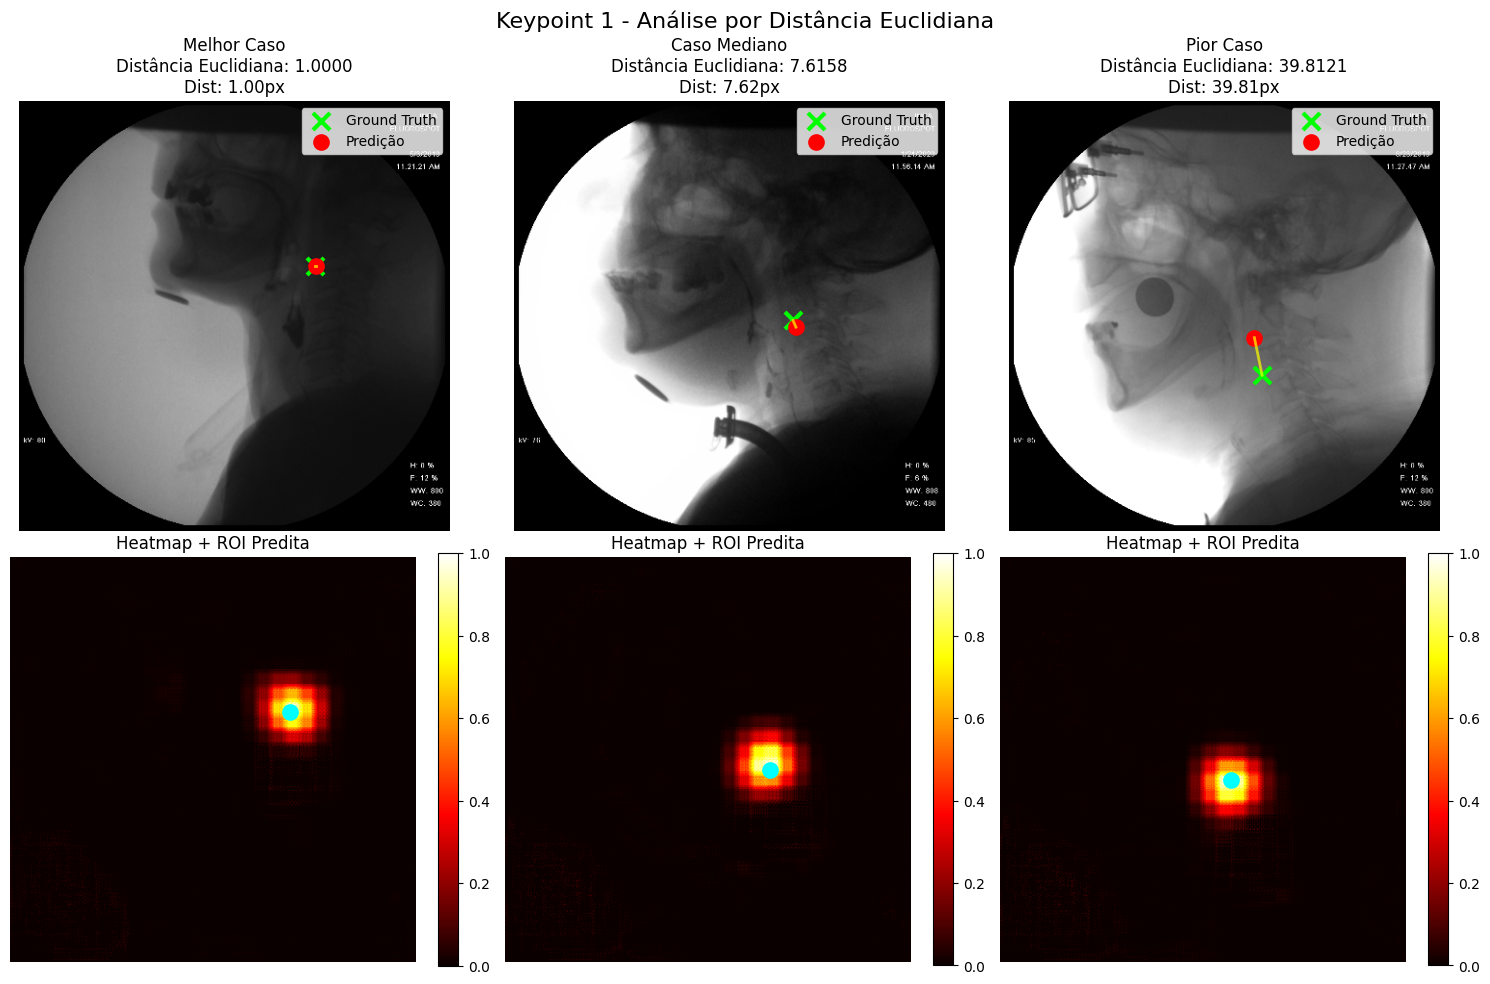


--- Visualizações para Keypoint 2 ---
✓ Figura salva: figs\FullHRNet_ImageNet\MSELoss_200ep_32W\fold1\predictions_by_distance_keypoint2.png


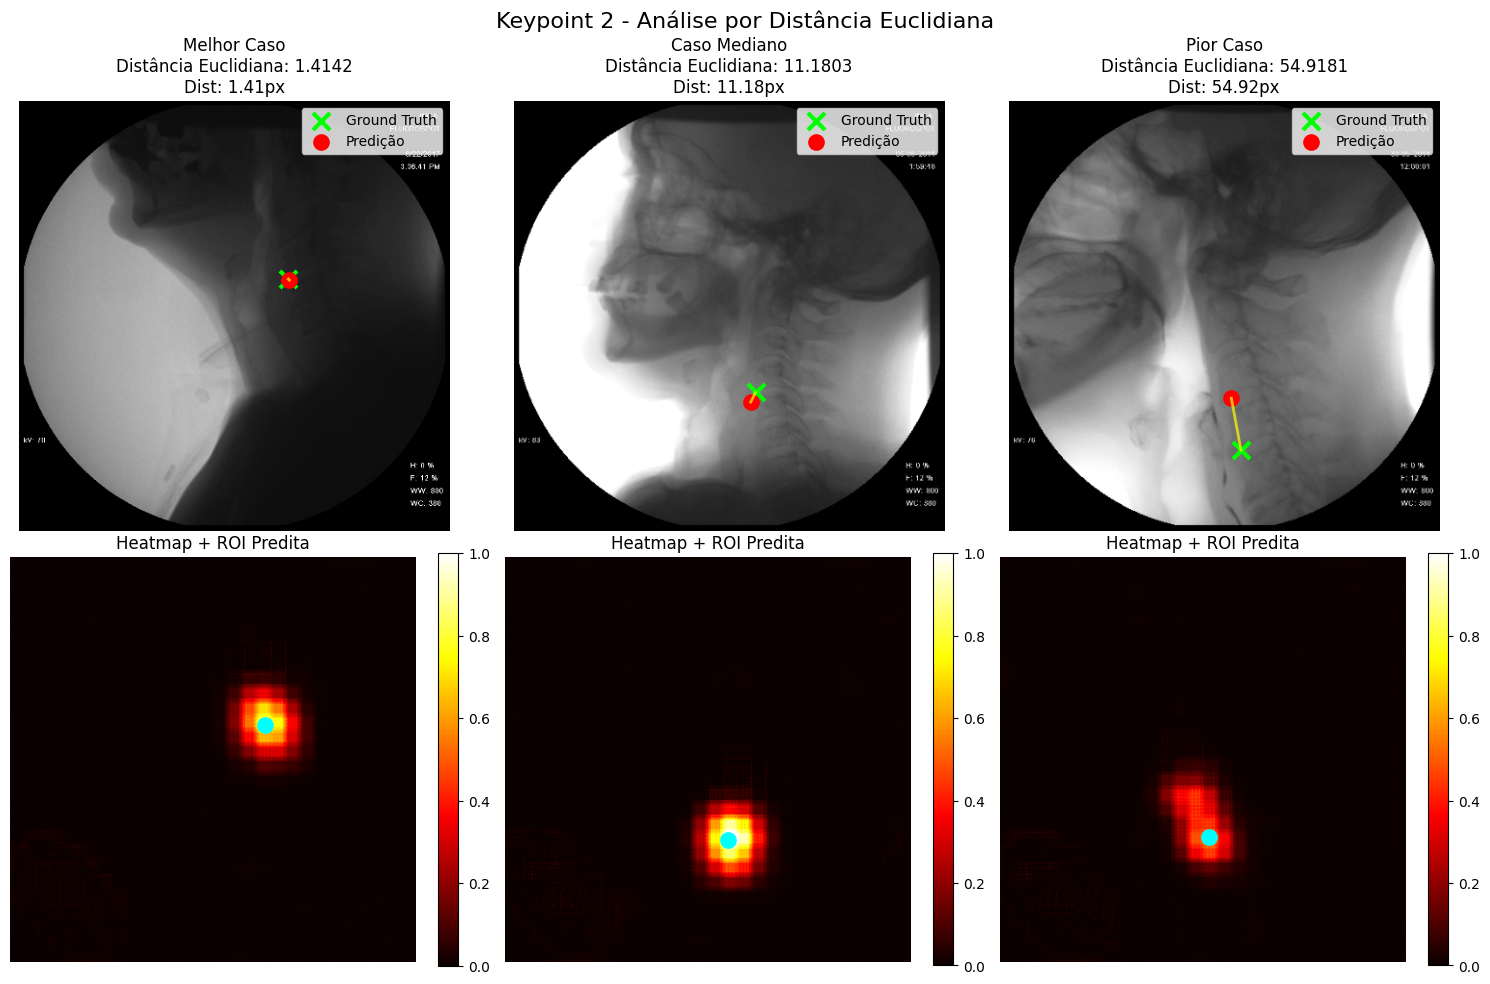


--- Visualizações para Keypoint 1 ---
✓ Figura salva: figs\FullHRNet_ImageNet\MSELoss_200ep_32W\fold1\predictions_by_loss_keypoint1.png


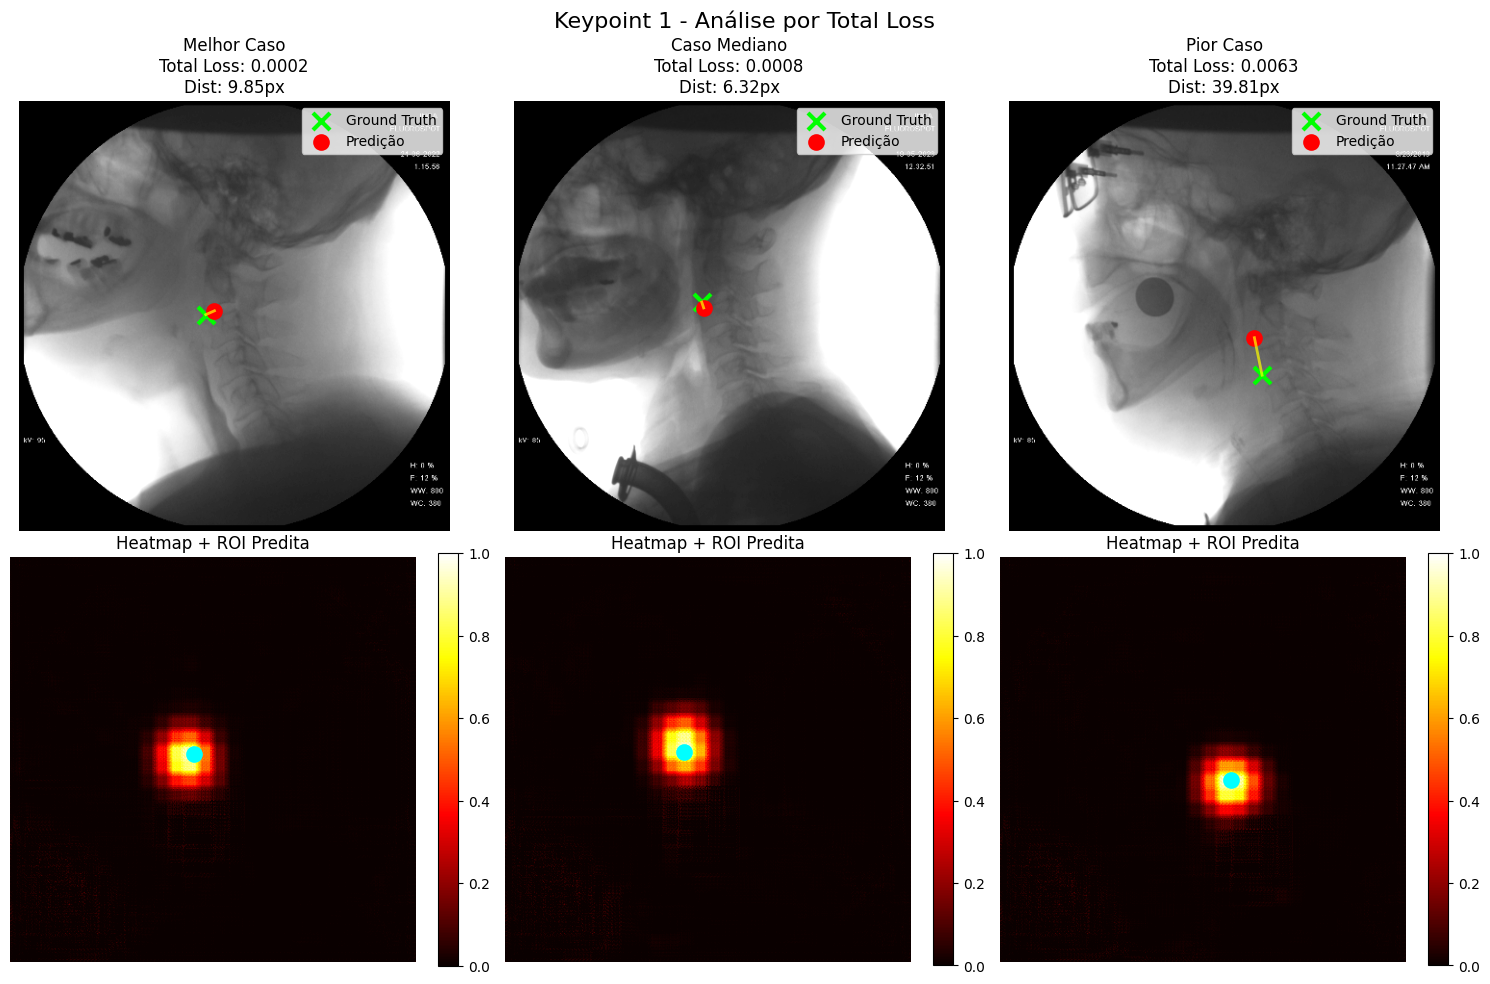


--- Visualizações para Keypoint 2 ---
✓ Figura salva: figs\FullHRNet_ImageNet\MSELoss_200ep_32W\fold1\predictions_by_loss_keypoint2.png


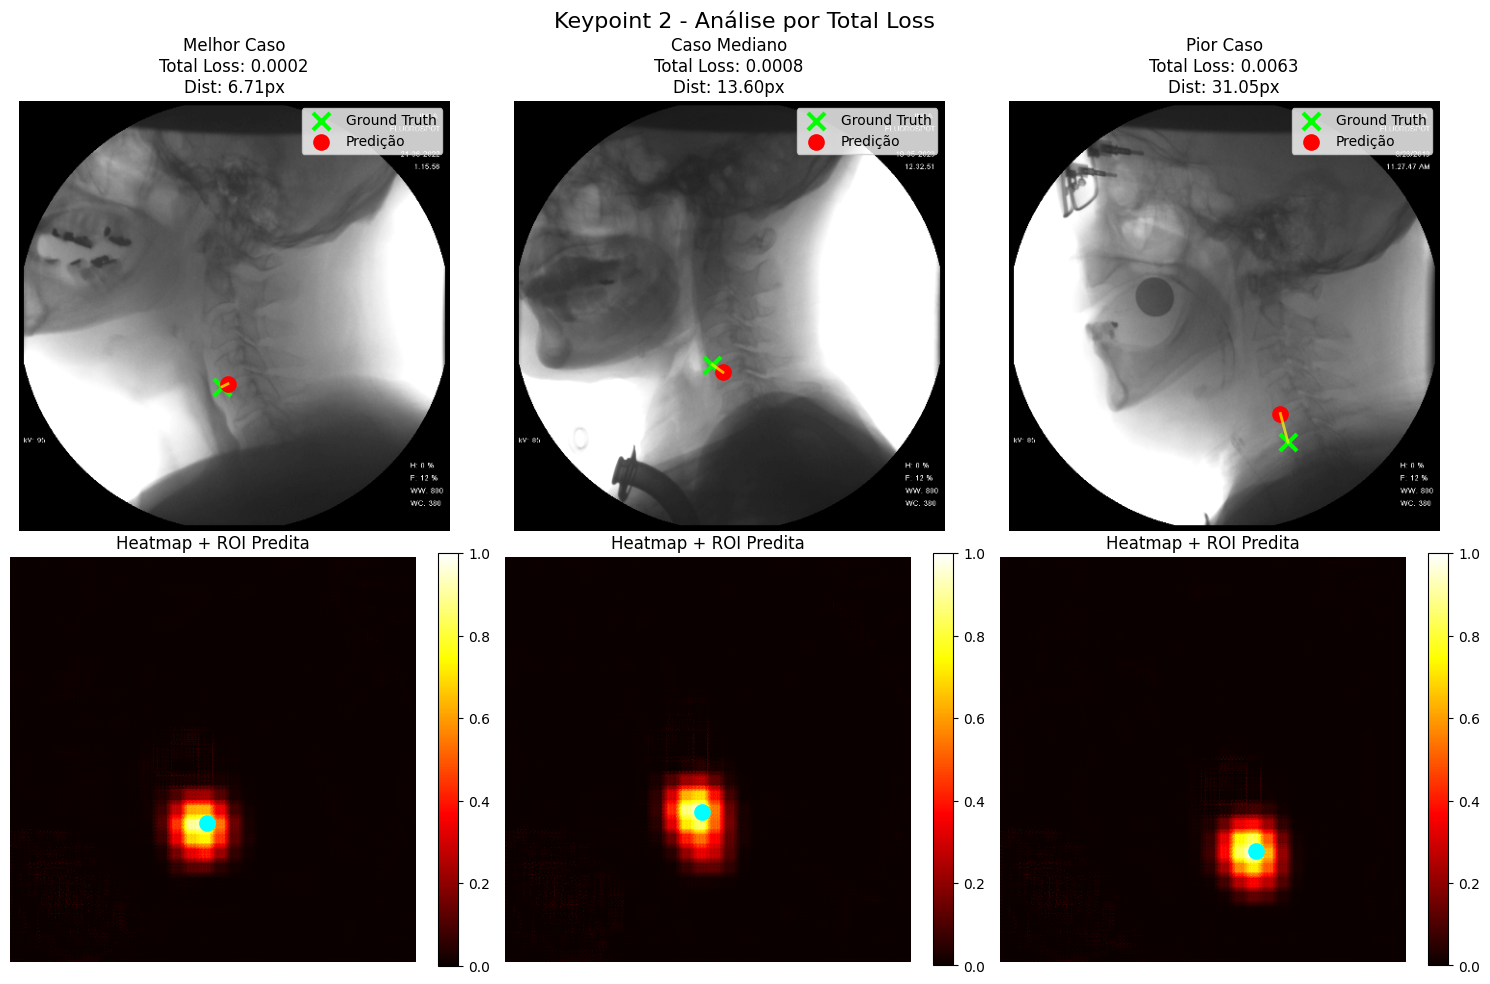

RELATÓRIO DE AVALIAÇÃO NO CONJUNTO DE TESTE

Número de amostras: 178

----------------------------------------------------------------------
LOSS TOTAL
----------------------------------------------------------------------
Média:    0.001304
Mediana:  0.000839
Std:      0.001202
Min:      0.000249
Max:      0.006285

----------------------------------------------------------------------
HEATMAP LOSS
----------------------------------------------------------------------
Média:    0.001304
Mediana:  0.000839
Std:      0.001202

----------------------------------------------------------------------
ROI LOSS
----------------------------------------------------------------------
Média:    0.000000
Mediana:  0.000000
Std:      0.000000

----------------------------------------------------------------------
KEYPOINT 1 - DISTÂNCIA EUCLIDIANA (pixels)
----------------------------------------------------------------------
Média:    9.60
Mediana:  7.62
Std:      7.43
Min:      1.00
Max:      39.8

c:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\.venv\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [ ]:
# Verificando Inferência no conjunto de Teste
path_config_fullhrnet = os.path.join("data\model_weights",config_fullhrnet.model_name,'config.pkl')
display_inference(path_config_fullhrnet)

## **Two Stages ResNet**

### **Configuração**

In [2]:
# Parametros Básicos Iniciais

# Transformações
output_dim = (448, 448)

transform_augmentation_offline =  A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(rotate=(-45, 45), shear=(-10, 10), p=1.0),
    A.Affine(scale=(0.75, 1.25), p=1.0),
    A.ColorJitter(brightness=(0.8, 1.2), contrast=0, saturation=0, hue=0, p=1.0),
    A.Resize(output_dim[0], output_dim[1])
    ],
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
    )

transform_puro = A.Compose([A.Resize(output_dim[0], output_dim[1]),
                       ToTensorV2()],
                      keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

# Configuração
config_resnet = TrainingConfig(
         path_dataframe = "data/metadados/video_frame_metadata.csv",
         model_class    = TwoStageResNet,
         model_kwargs = {},
         test_size      = 0.2,
         n_folds        = 5,
         dataset_class  = VFSSImageDataset,
         sigma_heatmap  = 20,               # Não usa

         # Hiperparâmetros do Modelo
         epochs             = 80,
         learning_rate      = 0.01,
         batch_size         = 8,
         patience           = None,         # Não usa
         lr_patience        = None,         # Não usa
         optimizer          = torch.optim.SGD,
         optimizer_kwargs   = {"momentum": 0.9,
                               "weight_decay": 1e-4},
         scheduler          = torch.optim.lr_scheduler.ExponentialLR,
         scheduler_kwargs   = {"gamma": 0.95},

         # Offline Augmentation
         offline_augmentation    = True,
         transform_augmentation  = transform_augmentation_offline,
         augmentation_dir        = "data/frames_augmentation",
         n_aug                   = 1,

         # Funções e Transformações
         output_dim           = output_dim,
         modify_input_fn      = None,
         collate_fn           = custom_collate_fn,
         transform_train      = transform_puro,
         transform_validation = transform_puro,

         # Função de Loss
         criterion_roi       = None,
         criterion_heatmap   = None,
         criterion_keypoints = nn.MSELoss(),
         weight_roi          = 0.0,
         weight_heatmap      = 0.0,
         weight_penalty      = 0.0,
         weight_keypoints    = 1.0,

         # Outros
         device          = "cuda" if torch.cuda.is_available() else "cpu",
         predict_roi     = False
         )

# Avaliando Status do Uso da GPU
avalia_status_GPU()

Folds all: 92
Test: 23
Overall Dataset - Videos: 234 | Patients: 115 | Frames: 973 (100.0%)
Training + Validation Set - Videos: 192 | Patients: 92 | Frames: 795 (81.7%)
Test Set - Videos: 42 | Patients: 23 | Frames: 178 (18.3%)

Fold 1 - Videos: 41 | Patients: 19 | Frames: 174 (17.9%)
Fold 2 - Videos: 56 | Patients: 19 | Frames: 230 (23.6%)
Fold 3 - Videos: 40 | Patients: 18 | Frames: 168 (17.3%)
Fold 4 - Videos: 26 | Patients: 18 | Frames: 108 (11.1%)
Fold 5 - Videos: 29 | Patients: 18 | Frames: 115 (11.8%)


,split_name,n_videos,n_patients,n_frames,percentage_of_initial_frames,video_ids
0,fold_1,41,19,174,0.178828,"[101, 102, 103, 104, 105, 106, 107, 108, 109, ..."
1,fold_2,56,19,230,0.236382,"[129, 130, 131, 132, 136, 137, 138, 139, 140, ..."
2,fold_3,40,18,168,0.172662,"[122, 123, 125, 126, 127, 128, 152, 153, 154, ..."
3,fold_4,26,18,108,0.110997,"[10, 113, 114, 115, 116, 117, 118, 119, 120, 1..."
4,fold_5,29,18,115,0.118191,"[192, 193, 194, 195, 196, 197, 198, 199, 200, ..."
5,test_set,42,23,178,0.182939,"[100, 11, 13, 142, 143, 144, 145, 146, 147, 14..."



VERIFICAÇÃO DE GPU
PyTorch version: 2.2.2+cu121
CUDA disponível: True
CUDA version: 12.1
GPU: NVIDIA GeForce RTX 2080 Ti
Número de GPUs: 1



### **Treino/Validação**

In [ ]:
# TREINO

# Holdout Training sem tunagem
results = holdout(
    df_train=pd.concat([config_resnet.list_df_folds[j] for j in range(1,config_resnet.n_folds)], ignore_index=True),
    df_val=config_resnet.list_df_folds[0],
    config=config_resnet,
)

Arquivos antigos de augmentation apagados!


Treinando:  28%|██▊       | 109/389 [01:17<01:59,  2.34it/s]

### **Teste**


INICIANDO AVALIAÇÃO NO CONJUNTO DE TESTE
✓ Modelo carregado: data\model_weights\TwoStageResNet\MSELoss_1ep\1784300423\fold_1_best.pth
  Epoch: 0
  Val Loss: 0.3461

Avaliando 178 amostras do conjunto de teste...


Avaliando:   1%|          | 1/178 [00:00<01:25,  2.06it/s]

Antes Squeeze:  tensor([[[-0.0182, -0.0088],
         [-0.4336, -0.0011]]], device='cuda:0')
Depois Squeeze:  tensor([[-0.0182, -0.0088],
        [-0.4336, -0.0011]], device='cuda:0')
Pontos Reais:  tensor([[227., 300.],
        [328., 317.]], device='cuda:0')


Avaliando:   2%|▏         | 3/178 [00:00<00:35,  4.95it/s]

Antes Squeeze:  tensor([[[-0.0182, -0.0088],
         [-0.4336, -0.0011]]], device='cuda:0')
Depois Squeeze:  tensor([[-0.0182, -0.0088],
        [-0.4336, -0.0011]], device='cuda:0')
Pontos Reais:  tensor([[225., 301.],
        [328., 317.]], device='cuda:0')
Antes Squeeze:  tensor([[[-0.0182, -0.0088],
         [-0.4336, -0.0011]]], device='cuda:0')
Depois Squeeze:  tensor([[-0.0182, -0.0088],
        [-0.4336, -0.0011]], device='cuda:0')
Pontos Reais:  tensor([[227., 303.],
        [326., 319.]], device='cuda:0')


...

Antes Squeeze:  tensor([[[-0.0182, -0.0088],
         [-0.4336, -0.0011]]], device='cuda:0')
Depois Squeeze:  tensor([[-0.0182, -0.0088],
        [-0.4336, -0.0011]], device='cuda:0')
Pontos Reais:  tensor([[270., 205.],
        [354., 244.]], device='cuda:0')
Antes Squeeze:  tensor([[[-0.0182, -0.0088],
         [-0.4336, -0.0011]]], device='cuda:0')
Depois Squeeze:  tensor([[-0.0182, -0.0088],
        [-0.4336, -0.0011]], device='cuda:0')
Pontos Reais:  tensor([[269., 206.],
        [354., 247.]], device='cuda:0')


Avaliando:  99%|█████████▉| 176/178 [00:20<00:00,  9.51it/s]

Antes Squeeze:  tensor([[[-0.0182, -0.0088],
         [-0.4336, -0.0011]]], device='cuda:0')
Depois Squeeze:  tensor([[-0.0182, -0.0088],
        [-0.4336, -0.0011]], device='cuda:0')
Pontos Reais:  tensor([[237., 255.],
        [303., 251.]], device='cuda:0')
Antes Squeeze:  tensor([[[-0.0182, -0.0088],
         [-0.4336, -0.0011]]], device='cuda:0')
Depois Squeeze:  tensor([[-0.0182, -0.0088],
        [-0.4336, -0.0011]], device='cuda:0')
Pontos Reais:  tensor([[239., 245.],
        [307., 243.]], device='cuda:0')
Antes Squeeze:  tensor([[[-0.0182, -0.0088],
         [-0.4336, -0.0011]]], device='cuda:0')
Depois Squeeze:  tensor([[-0.0182, -0.0088],
        [-0.4336, -0.0011]], device='cuda:0')
Pontos Reais:  tensor([[238., 255.],
        [303., 253.]], device='cuda:0')


Avaliando: 100%|██████████| 178/178 [00:20<00:00,  8.73it/s]

Antes Squeeze:  tensor([[[-0.0182, -0.0088],
         [-0.4336, -0.0011]]], device='cuda:0')
Depois Squeeze:  tensor([[-0.0182, -0.0088],
        [-0.4336, -0.0011]], device='cuda:0')
Pontos Reais:  tensor([[238., 245.],
        [305., 246.]], device='cuda:0')

GERANDO VISUALIZAÇÕES


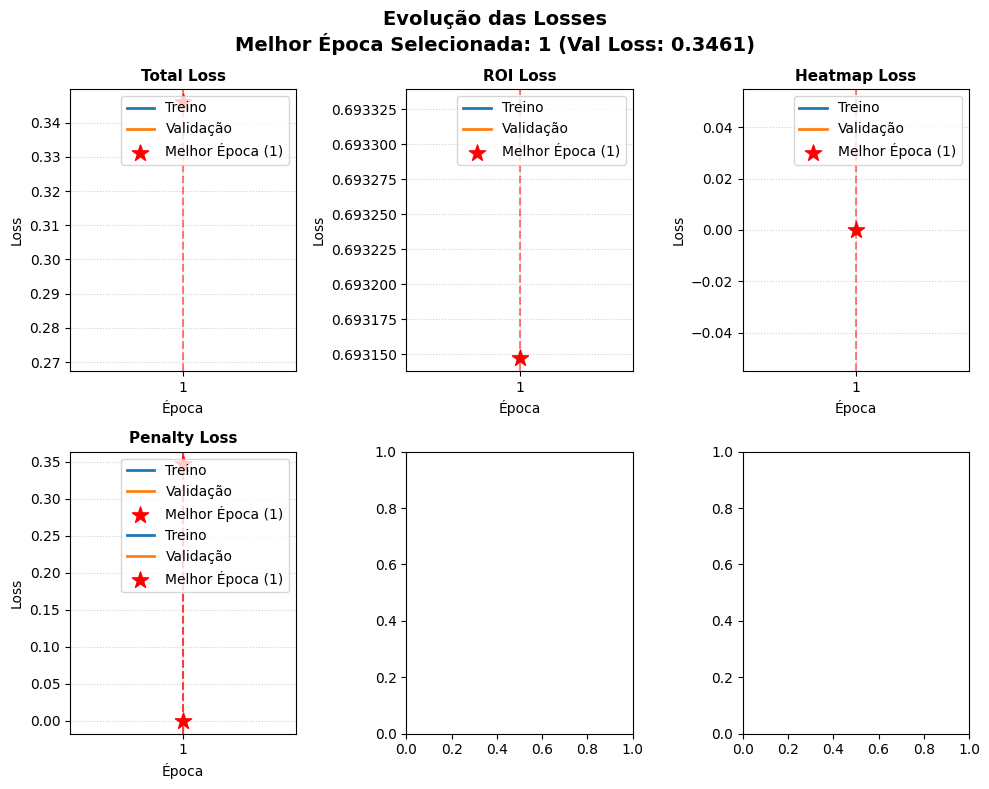

c:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\.venv\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


✓ Gráfico salvo: figs\TwoStageResNet\MSELoss_1ep\1784300423\fold1\loss_distributions.png


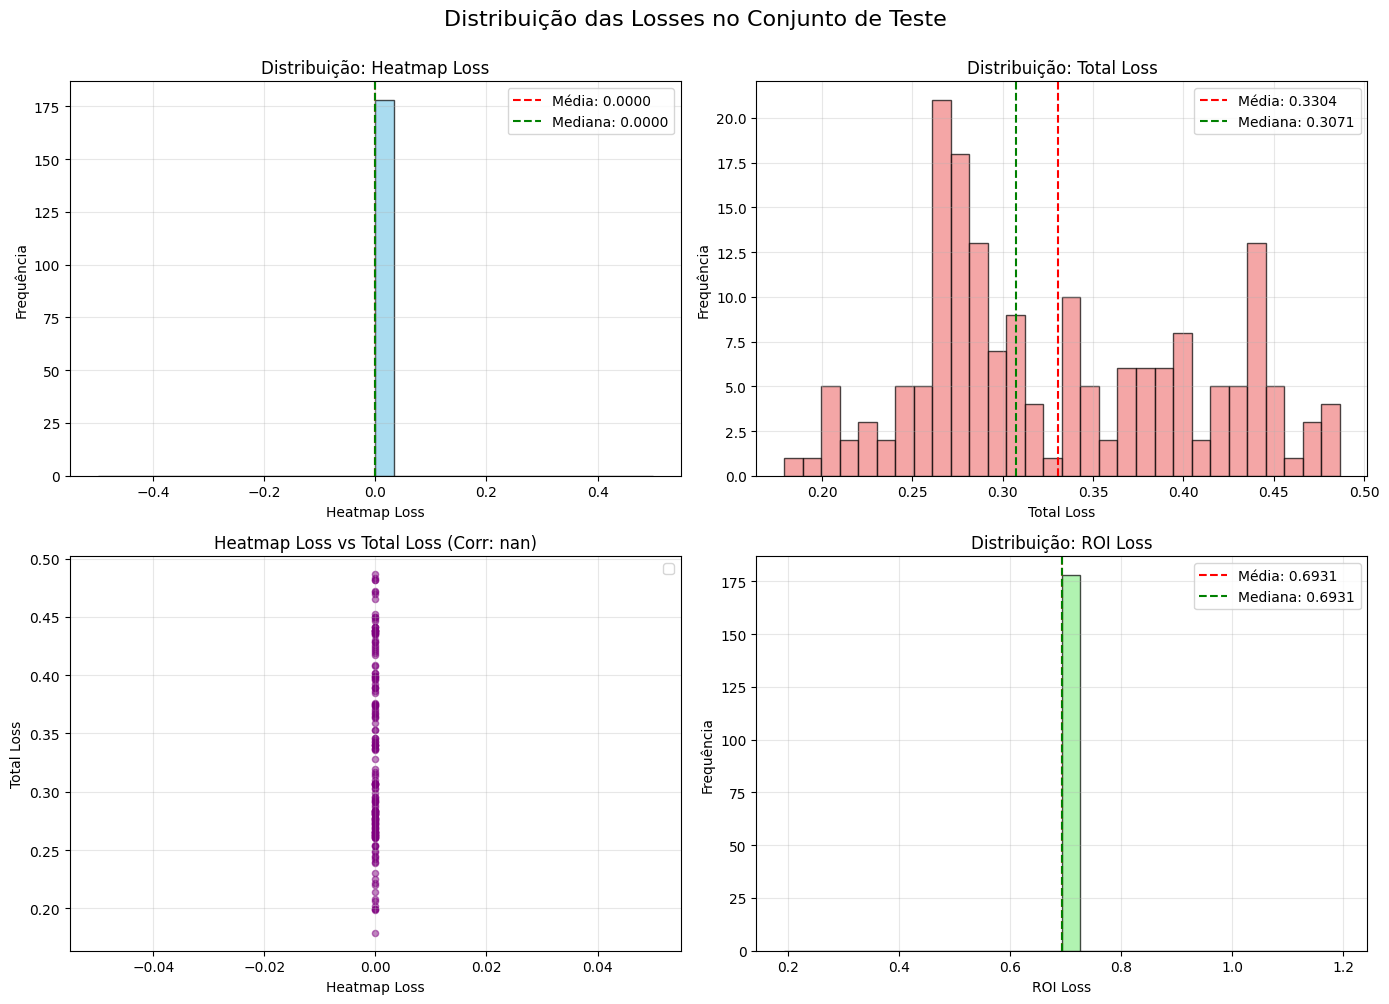

✓ Gráfico salvo: figs\TwoStageResNet\MSELoss_1ep\1784300423\fold1\keypoint_analysis.png


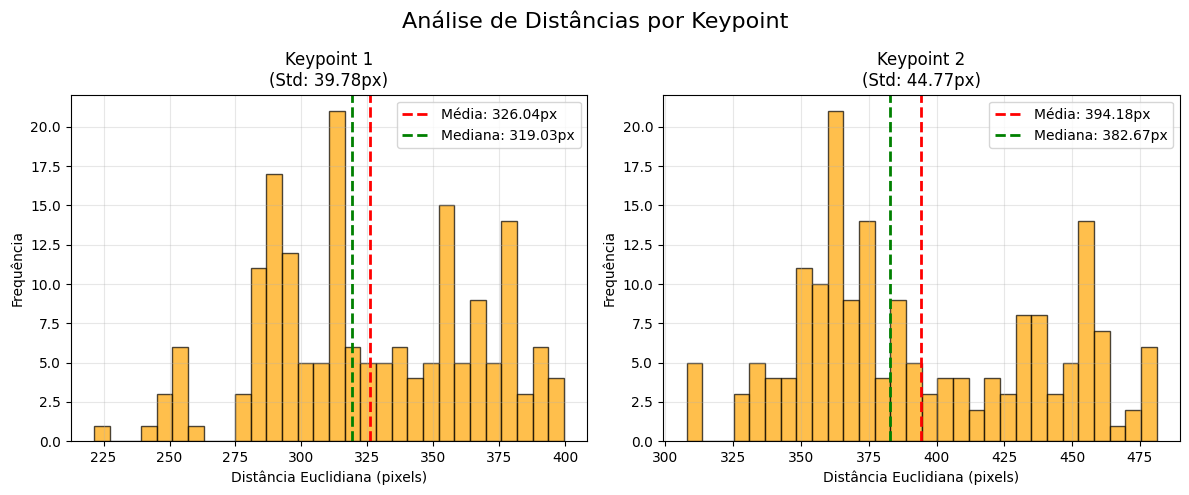


--- Visualizações para Keypoint 1 ---
✓ Figura salva: figs\TwoStageResNet\MSELoss_1ep\1784300423\fold1\predictions_by_distance_keypoint1.png


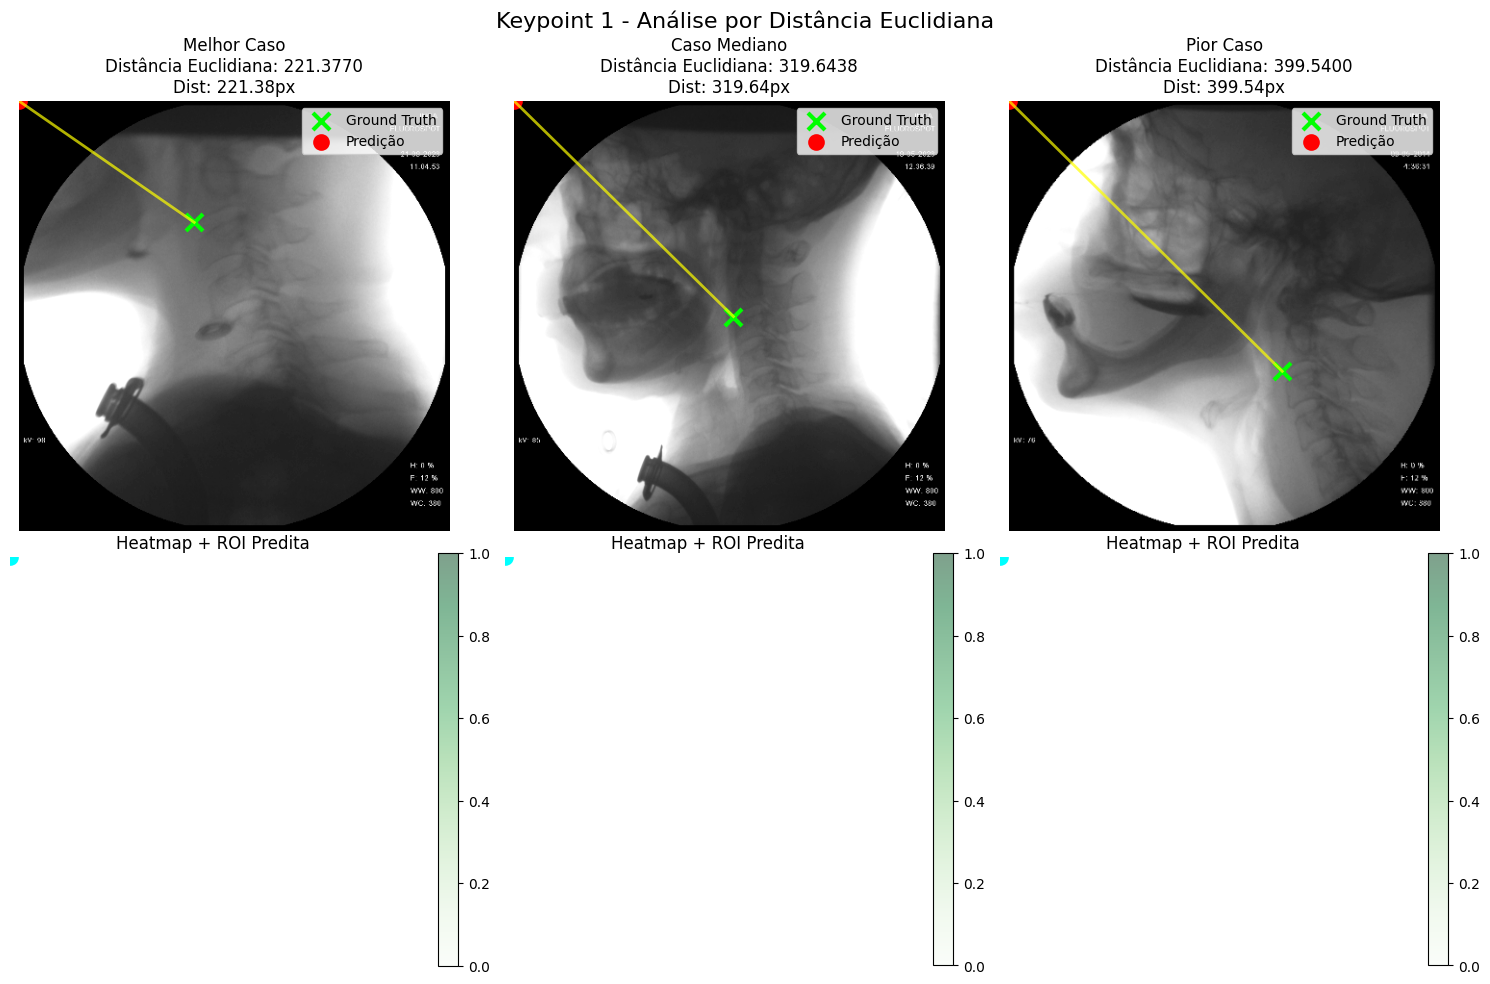


--- Visualizações para Keypoint 2 ---
✓ Figura salva: figs\TwoStageResNet\MSELoss_1ep\1784300423\fold1\predictions_by_distance_keypoint2.png


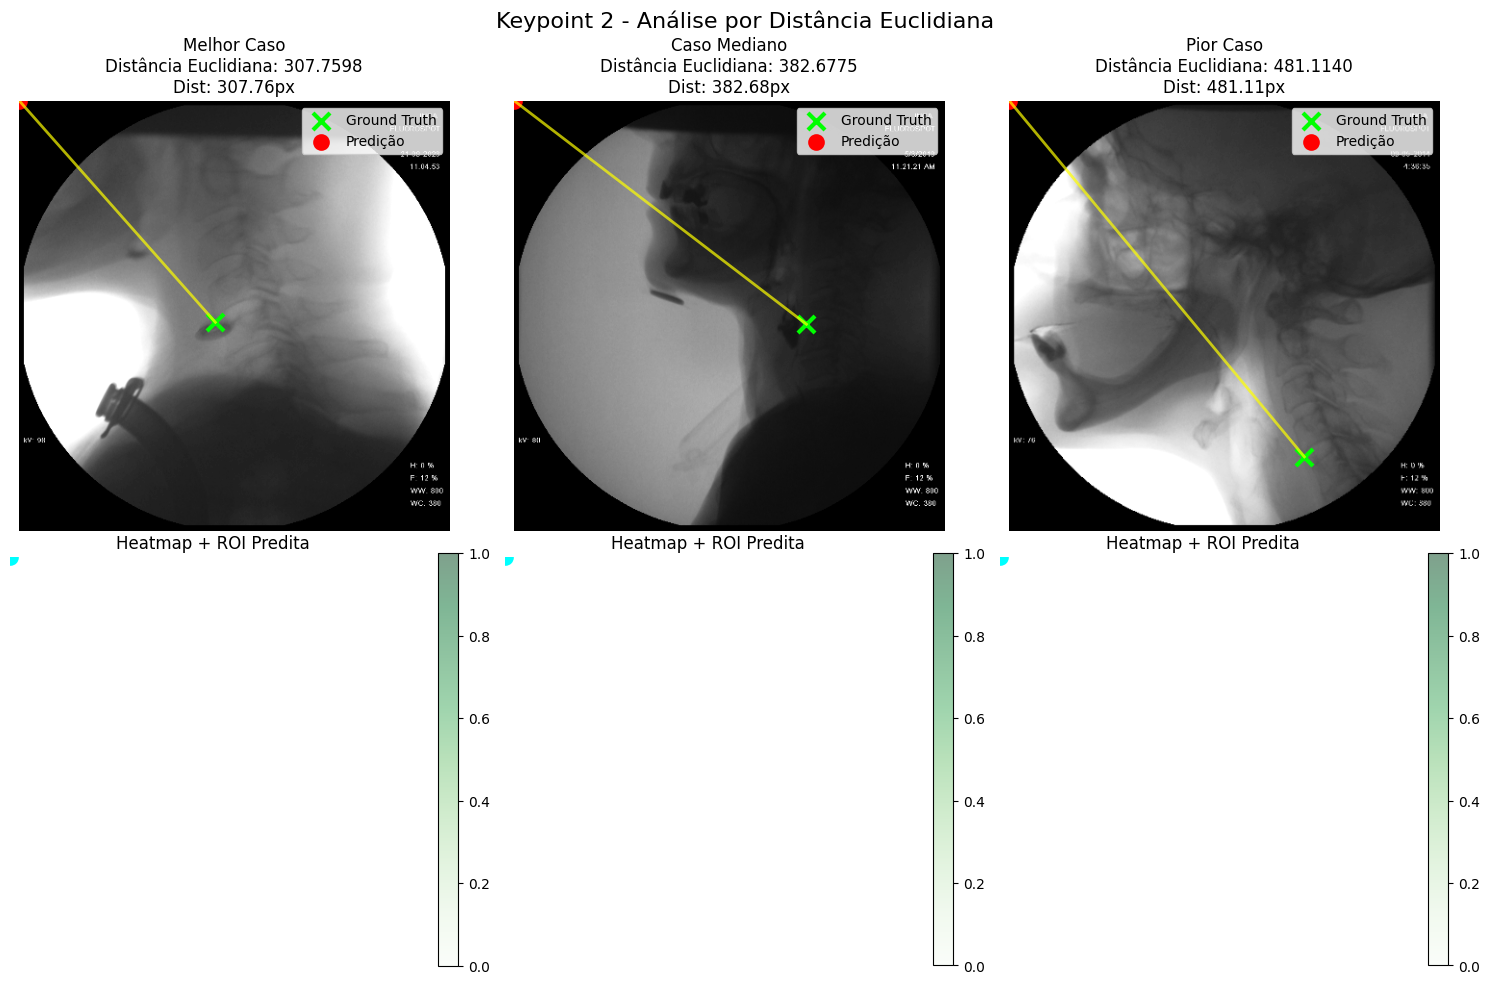


--- Visualizações para Keypoint 1 ---
✓ Figura salva: figs\TwoStageResNet\MSELoss_1ep\1784300423\fold1\predictions_by_loss_keypoint1.png


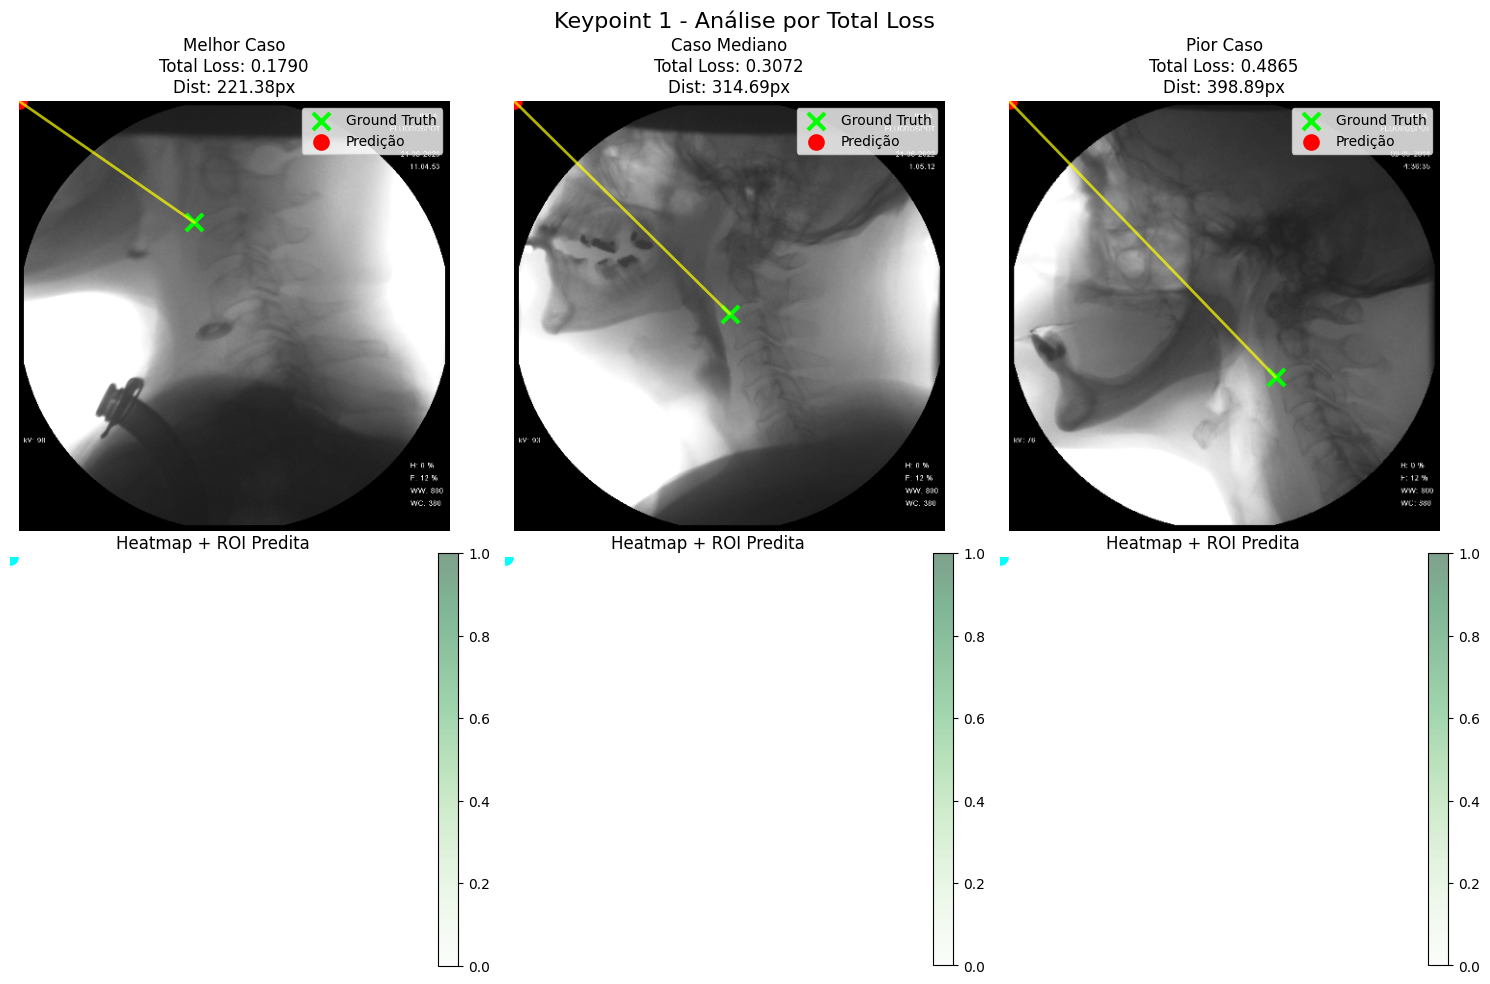


--- Visualizações para Keypoint 2 ---
✓ Figura salva: figs\TwoStageResNet\MSELoss_1ep\1784300423\fold1\predictions_by_loss_keypoint2.png


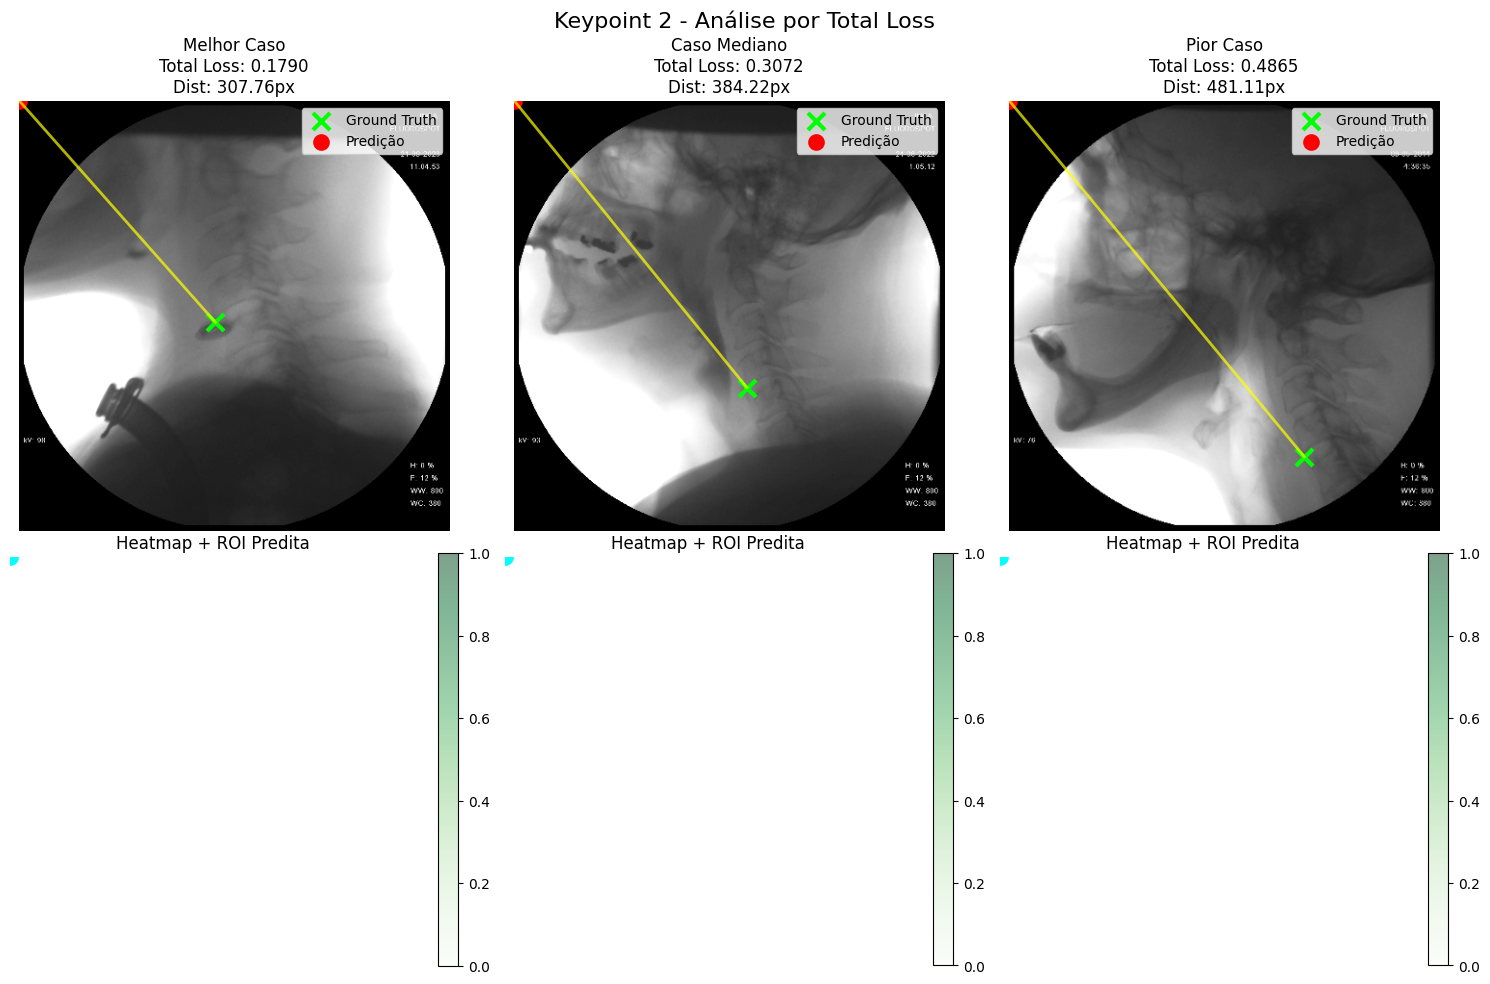

RELATÓRIO DE AVALIAÇÃO NO CONJUNTO DE TESTE

Número de amostras: 178

----------------------------------------------------------------------
LOSS TOTAL
----------------------------------------------------------------------
Média:    0.330425
Mediana:  0.307144
Std:      0.075730
Min:      0.179025
Max:      0.486518

----------------------------------------------------------------------
HEATMAP LOSS
----------------------------------------------------------------------
Média:    0.000000
Mediana:  0.000000
Std:      0.000000

----------------------------------------------------------------------
ROI LOSS
----------------------------------------------------------------------
Média:    0.693147
Mediana:  0.693147
Std:      0.000000

----------------------------------------------------------------------
KEYPOINT 1 - DISTÂNCIA EUCLIDIANA (pixels)
----------------------------------------------------------------------
Média:    326.04
Mediana:  319.03
Std:      39.78
Min:      221.38
Max:   

In [ ]:
# Verificando Inferência no conjunto de Teste
path_config_resnet = os.path.join("data\model_weights",config_resnet.model_name,'config.pkl')
#path_config_resnet = os.path.join("data\model_weights",r"TwoStageResNet\MSELoss_1ep\1784300423",'config.pkl')
display_inference(path_config_resnet)